In [46]:
import numpy as np
import json
import pickle
import matplotlib.pyplot as plt

In [47]:
def set_style():
    plt.rcParams["text.usetex"] = True
    font = {"family": "normal", "weight": "bold", "size": 20}
    plt.rc("font", **font)

In [48]:
set_style()

In [49]:
def reader(path_params):
    with open(path_params, "r") as file:
        params = json.load(file)
    print(params)
    return params

In [50]:
def load_list_with_pickle(file_name):
    with open(file_name, "rb") as file:
        result = pickle.load(file)
    return result

In [51]:
params_path = "params/experiment_2_c.json"
input_path = "results/experiment_2_c.pkl"
result_path = "results/experiment_2_c/"

In [52]:
params_global = reader(params_path)

{'data': {'sample_sizes': [500], 'feature_number': 100, 'label_number': 10, 'avg_label_number': 5, 'cal_size': 0.3, 'proper_cal_size': 0.5}, 'predictor': {'n_estimators_min': 10, 'n_estimators_max': 100, 'criterion': ['gini', 'entropy'], 'lam_numbers': [10, 20, 30, 40, 50]}, 'risk': {'control_level': 0.2}}


In [53]:
results__ = load_list_with_pickle(input_path)

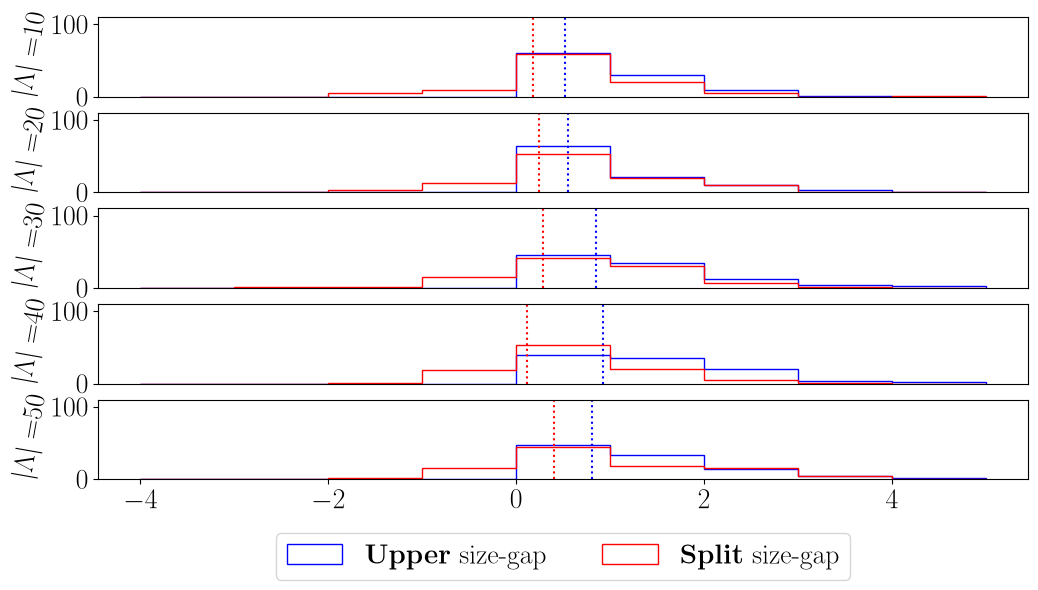

In [54]:
# bins = range(
#     -params_global["data"]["label_number"] - 2, params_global["data"]["label_number"] + 2
# )
bins = range(-4, 6)
y_max = 110
for results_ in results__:
    fig, axs = plt.subplots(len(results_), figsize=(12, 6))
    for index, (results, ax, lam_number) in enumerate(zip(
        results_, axs, params_global["predictor"]["lam_numbers"]
    )):
        upper_size_gap = np.array(results["size"]["Upper"]) - np.array(results["size"]["Oracle"])
        average_upper_size_gap = np.mean(upper_size_gap)
        ax.hist(
            upper_size_gap,
            bins=bins,
            histtype="step",
            color="blue",
            label = r"\textbf{Upper} size-gap"
        )
        ax.plot(
            [average_upper_size_gap, average_upper_size_gap],
            [0, y_max],
            color="blue",
            linestyle="dotted",
            # label="Average Upper size-gap"
        )
    
        split_size_gap = np.array(results["size"]["Split"]) - np.array(results["size"]["Oracle"])
        average_split_size_gap = np.mean(split_size_gap)
        ax.hist(
            split_size_gap,
            bins=bins,
            histtype="step",
            color="red",
            label = r"\textbf{Split} size-gap"
        )
        ax.plot(
            [average_split_size_gap, average_split_size_gap],
            [0, y_max],
            color="red",
            linestyle="dotted",
            # label="Average Split size-gap"
        )

        ax.set_ylabel(r"$|\Lambda|=$"+"{}".format(lam_number), rotation=80)
        
        
        if index in range(len(results_)-1):
            ax.set_xticks([])
        
        ax.set_ylim(0, y_max)
        
        if index == (len(results_)-1):
            ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.5),fancybox=True, ncol=4)


    fig.savefig(
        result_path
        + "size_gap"
        + ".png",
        bbox_inches="tight", dpi=300
    )
    

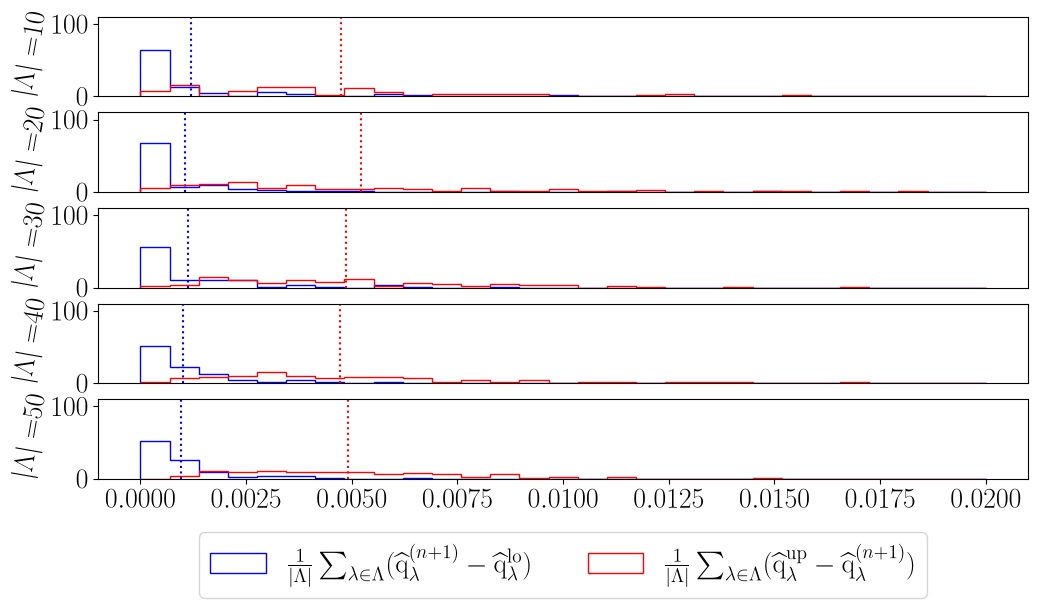

In [55]:
bins=np.linspace(0, 0.02, 30)
y_max = 110
for results_ in results__:
    fig, axs = plt.subplots(len(results_), figsize=(12, 6))
    for index, (results, ax, lam_number) in enumerate(zip(
        results_, axs, params_global["predictor"]["lam_numbers"]
    )):
        average_lower_order_gap = np.mean(results["avg_order_gap"]["Lower"])
        ax.hist(
            results["avg_order_gap"]["Lower"],
            bins=bins,
            histtype="step",
            color="blue",
            label = r"$\frac{1}{|\Lambda|} \sum_{\lambda \in \Lambda} (\widehat{\mathrm{q}}_{\lambda}^{(n+1)} - \widehat{\mathrm{q}}_{\lambda}^{\mathrm{lo}})$"
        )
        ax.plot(
            [average_lower_order_gap, average_lower_order_gap],
            [0, y_max],
            color="blue",
            linestyle="dotted",
        )
    
        average_upper_order_gap = np.mean(results["avg_order_gap"]["Upper"])
        ax.hist(
            results["avg_order_gap"]["Upper"],
            bins=bins,
            histtype="step",
            color="red",
            label = r"$\frac{1}{|\Lambda|} \sum_{\lambda \in \Lambda} (\widehat{\mathrm{q}}_{\lambda}^{\mathrm{up}} - \widehat{\mathrm{q}}_{\lambda}^{(n+1)})$"
        )
        ax.plot(
            [average_upper_order_gap, average_upper_order_gap],
            [0, y_max],
            color="red",
            linestyle="dotted",
        )

        ax.set_ylabel(r"$|\Lambda|=$"+"{}".format(lam_number), rotation=80)
        
        
        if index in range(len(results_)-1):
            ax.set_xticks([])
        
        ax.set_ylim(0, y_max)
        
        if index == (len(results_)-1):
            ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.5),fancybox=True, ncol=4)

        fig.savefig(
            result_path
            + "avg_order_gap"
            + ".png",
            bbox_inches="tight", dpi=300
        )

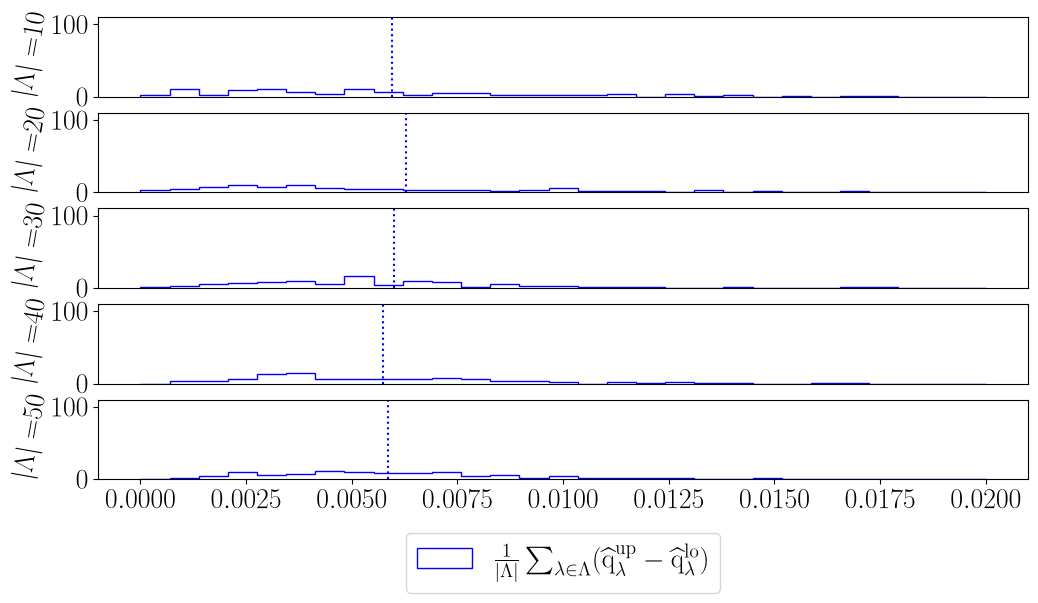

In [56]:
bins=np.linspace(0, 0.02, 30)
y_max = 110
for results_ in results__:
    fig, axs = plt.subplots(len(results_), figsize=(12, 6))
    for index, (results, ax, lam_number) in enumerate(zip(
        results_, axs, params_global["predictor"]["lam_numbers"]
    )):
        avg_order_gap = (
            np.array(results["avg_order_gap"]["Lower"])
            + np.array(results["avg_order_gap"]["Upper"])
        )
        average_lower_order_gap = np.mean(avg_order_gap)
        ax.hist(
            avg_order_gap,
            bins=bins,
            histtype="step",
            color="blue",
            label = r"$\frac{1}{|\Lambda|} \sum_{\lambda \in \Lambda} (\widehat{\mathrm{q}}_{\lambda}^{\mathrm{up}} - \widehat{\mathrm{q}}_{\lambda}^{\mathrm{lo}})$"
        )
        ax.plot(
            [average_lower_order_gap, average_lower_order_gap],
            [0, y_max],
            color="blue",
            linestyle="dotted",
        )

        ax.set_ylabel(r"$|\Lambda|=$"+"{}".format(lam_number), rotation=80)
        
        
        if index in range(len(results_)-1):
            ax.set_xticks([])
        
        ax.set_ylim(0, y_max)
        
        if index == (len(results_)-1):
            ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.5),fancybox=True, ncol=4)
    fig.savefig(
        result_path
        + "avg_order_gap_0"
        + ".png",
        bbox_inches="tight", dpi=300
    )

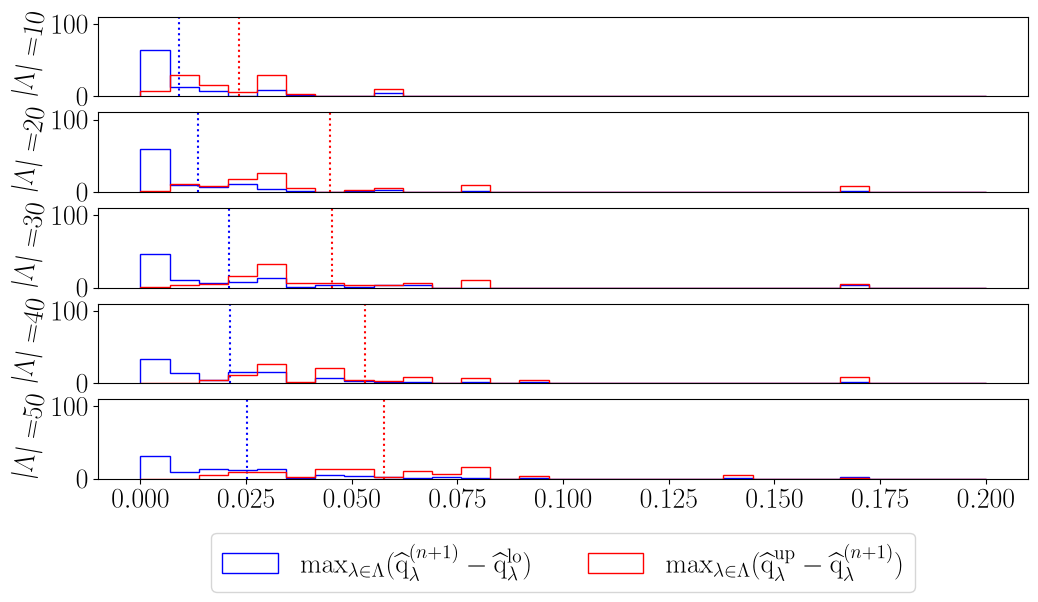

In [57]:
bins=np.linspace(0, 0.2, 30)
y_max = 110
for results_ in results__:
    fig, axs = plt.subplots(len(results_), figsize=(12, 6))
    for index, (results, ax, lam_number) in enumerate(zip(
        results_, axs, params_global["predictor"]["lam_numbers"]
    )):
        average_lower_order_gap = np.mean(results["max_order_gap"]["Lower"])
        ax.hist(
            results["max_order_gap"]["Lower"],
            bins=bins,
            histtype="step",
            color="blue",
            label = r"$ \max_{\lambda \in \Lambda} (\widehat{\mathrm{q}}_{\lambda}^{(n+1)} - \widehat{\mathrm{q}}_{\lambda}^{\mathrm{lo}})$"
        )
        ax.plot(
            [average_lower_order_gap, average_lower_order_gap],
            [0, y_max],
            color="blue",
            linestyle="dotted",
        )
    
        average_upper_order_gap = np.mean(results["max_order_gap"]["Upper"])
        ax.hist(
            results["max_order_gap"]["Upper"],
            bins=bins,
            histtype="step",
            color="red",
            label = r"$\max_{\lambda \in \Lambda} (\widehat{\mathrm{q}}_{\lambda}^{\mathrm{up}} - \widehat{\mathrm{q}}_{\lambda}^{(n+1)})$"
        )
        ax.plot(
            [average_upper_order_gap, average_upper_order_gap],
            [0, y_max],
            color="red",
            linestyle="dotted",
        )

        ax.set_ylabel(r"$|\Lambda|=$"+"{}".format(lam_number), rotation=80)
        
        
        if index in range(len(results_)-1):
            ax.set_xticks([])
        
        ax.set_ylim(0, y_max)
        
        if index == (len(results_)-1):
            ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.5),fancybox=True, ncol=4)
            
    fig.savefig(
        result_path
        + "max_order_gap"
        + ".png",
        bbox_inches="tight", dpi=300
    )

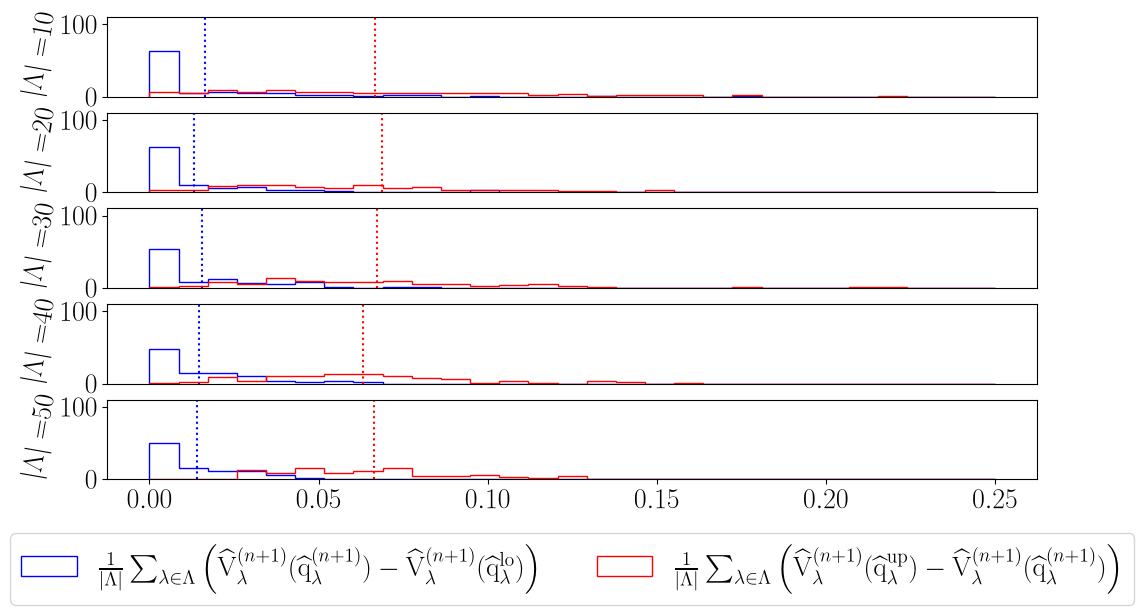

In [58]:
bins=np.linspace(0, 0.25, 30)
y_max = 110
for results_ in results__:
    fig, axs = plt.subplots(len(results_), figsize=(12, 6))
    for index, (results, ax, lam_number) in enumerate(zip(
        results_, axs, params_global["predictor"]["lam_numbers"]
    )):
        average_lower_size_gap = np.mean(results["avg_size_gap"]["Lower"])
        ax.hist(
            results["avg_size_gap"]["Lower"],
            bins=bins,
            histtype="step",
            color="blue",
            label =  r"$\frac{1}{|\Lambda|} \sum_{\lambda \in \Lambda} \left(\widehat{\mathrm{V}}_{\lambda}^{(n+1)}(\widehat{\mathrm{q}}_{\lambda}^{(n+1)}) - \widehat{\mathrm{V}}_{\lambda}^{(n+1)}(\widehat{\mathrm{q}}_{\lambda}^{\mathrm{lo}})\right)$"
        )
        ax.plot(
            [average_lower_size_gap, average_lower_size_gap],
            [0, y_max],
            color="blue",
            linestyle="dotted",
        )
    
        average_upper_size_gap = np.mean(results["avg_size_gap"]["Upper"])
        ax.hist(
            results["avg_size_gap"]["Upper"],
            bins=bins,
            histtype="step",
            color="red",
            label = r"$\frac{1}{|\Lambda|} \sum_{\lambda \in \Lambda} \left(\widehat{\mathrm{V}}_{\lambda}^{(n+1)}(\widehat{\mathrm{q}}_{\lambda}^{\mathrm{up}}) - \widehat{\mathrm{V}}_{\lambda}^{(n+1)}(\widehat{\mathrm{q}}_{\lambda}^{(n+1)})\right)$"
        )
        ax.plot(
            [average_upper_size_gap, average_upper_size_gap],
            [0, y_max],
            color="red",
            linestyle="dotted",
        )

        ax.set_ylabel(r"$|\Lambda|=$"+"{}".format(lam_number), rotation=80)
        
        
        if index in range(len(results_)-1):
            ax.set_xticks([])
        
        ax.set_ylim(0, y_max)
        
        if index == (len(results_)-1):
            ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.5),fancybox=True, ncol=4)

    fig.savefig(
        result_path
        + "avg_size_gap"
        + ".png",
        bbox_inches="tight", dpi=300
    )

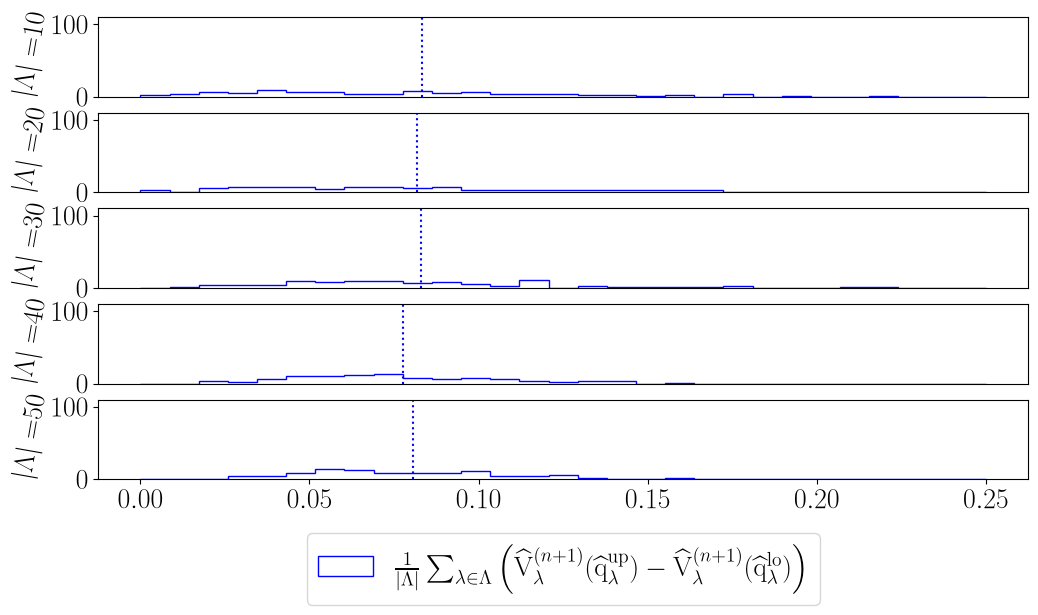

In [59]:
bins=np.linspace(0, 0.25, 30)
y_max = 110
for results_ in results__:
    fig, axs = plt.subplots(len(results_), figsize=(12, 6))
    for index, (results, ax, lam_number) in enumerate(zip(
        results_, axs, params_global["predictor"]["lam_numbers"]
    )):
        avg_size_gap = (
            np.array(results["avg_size_gap"]["Lower"])
            + np.array(results["avg_size_gap"]["Upper"])
        )
        average_size_gap = np.mean(avg_size_gap)
        ax.hist(
            avg_size_gap,
            bins=bins,
            histtype="step",
            color="blue",
            label = r"$\frac{1}{|\Lambda|} \sum_{\lambda \in \Lambda} \left(\widehat{\mathrm{V}}_{\lambda}^{(n+1)}(\widehat{\mathrm{q}}_{\lambda}^{\mathrm{up}}) - \widehat{\mathrm{V}}_{\lambda}^{(n+1)}(\widehat{\mathrm{q}}_{\lambda}^{\mathrm{lo}})\right)$"
        )
        ax.plot(
            [average_size_gap, average_size_gap],
            [0, y_max],
            color="blue",
            linestyle="dotted",
        )
        
        ax.set_ylabel(r"$|\Lambda|=$"+"{}".format(lam_number), rotation=80)
        
        
        if index in range(len(results_)-1):
            ax.set_xticks([])
        
        ax.set_ylim(0, y_max)
        
        if index == (len(results_)-1):
            ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.5),fancybox=True, ncol=4)

    fig.savefig(
        result_path
        + "avg_size_gap_0"
        + ".png",
        bbox_inches="tight", dpi=300
    )

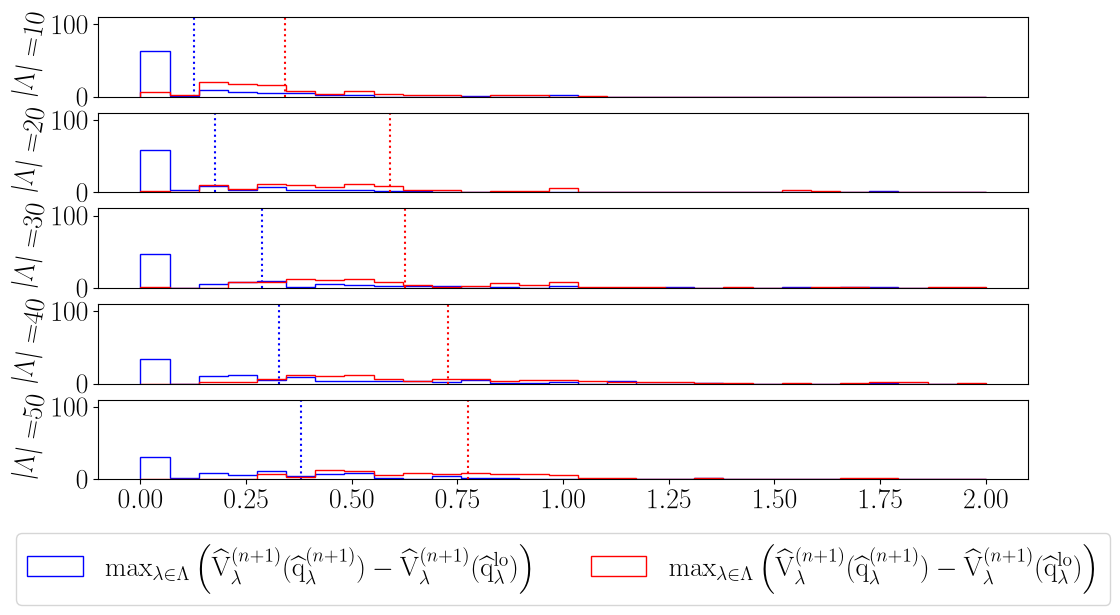

In [60]:
bins=np.linspace(0, 2, 30)
y_max = 110
for results_ in results__:
    fig, axs = plt.subplots(len(results_), figsize=(12, 6))
    for index, (results, ax, lam_number) in enumerate(zip(
        results_, axs, params_global["predictor"]["lam_numbers"]
    )):
        average_lower_size_gap = np.mean(results["max_size_gap"]["Lower"])
        ax.hist(
            results["max_size_gap"]["Lower"],
            bins=bins,
            histtype="step",
            color="blue",
            label = r"$\max_{\lambda \in \Lambda} \left(\widehat{\mathrm{V}}_{\lambda}^{(n+1)}(\widehat{\mathrm{q}}_{\lambda}^{(n+1)}) - \widehat{\mathrm{V}}_{\lambda}^{(n+1)}(\widehat{\mathrm{q}}_{\lambda}^{\mathrm{lo}})\right)$"
        )
        ax.plot(
            [average_lower_size_gap, average_lower_size_gap],
            [0, y_max],
            color="blue",
            linestyle="dotted",
        )
    
        average_upper_size_gap = np.mean(results["max_size_gap"]["Upper"])
        ax.hist(
            results["max_size_gap"]["Upper"],
            bins=bins,
            histtype="step",
            color="red",
            label = r"$\max_{\lambda \in \Lambda} \left(\widehat{\mathrm{V}}_{\lambda}^{(n+1)}(\widehat{\mathrm{q}}_{\lambda}^{(n+1)}) - \widehat{\mathrm{V}}_{\lambda}^{(n+1)}(\widehat{\mathrm{q}}_{\lambda}^{\mathrm{lo}})\right)$"
        )
        ax.plot(
            [average_upper_size_gap, average_upper_size_gap],
            [0, y_max],
            color="red",
            linestyle="dotted",
        )

        ax.set_ylabel(r"$|\Lambda|=$"+"{}".format(lam_number), rotation=80)
        
        
        if index in range(len(results_)-1):
            ax.set_xticks([])
        
        ax.set_ylim(0, y_max)
        
        if index == (len(results_)-1):
            ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.5),fancybox=True, ncol=4)

    fig.savefig(
        result_path
        + "max_size_gap"
        + ".png",
        bbox_inches="tight", dpi=300
    )

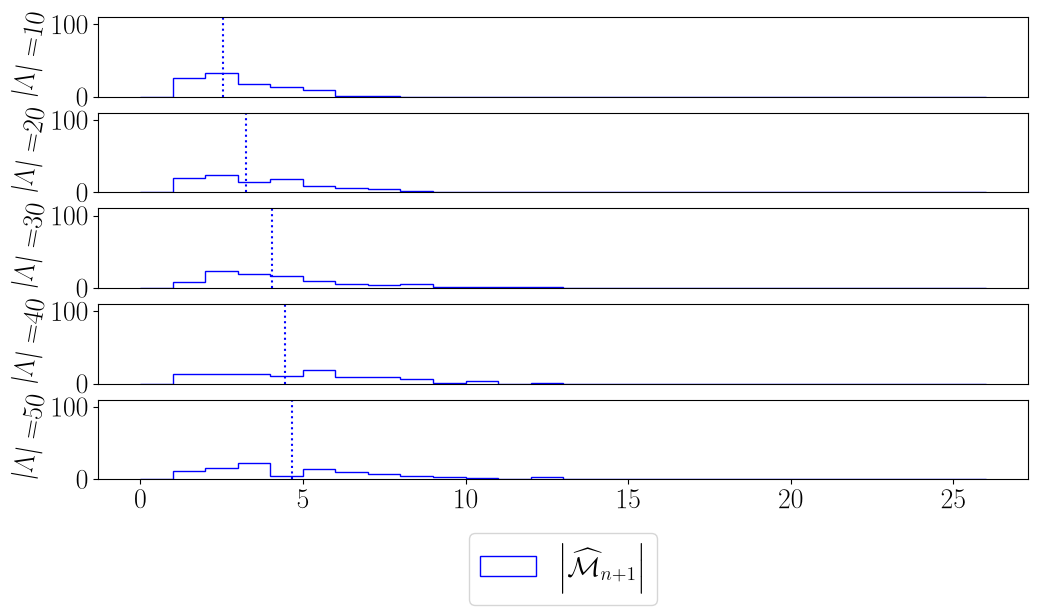

In [61]:
bins = range(27)
y_max = 110
for results_ in results__:
    fig, axs = plt.subplots(len(results_), figsize=(12, 6))
    for index, (results, ax, lam_number) in enumerate(zip(
        results_, axs, params_global["predictor"]["lam_numbers"]
    )):
        average_cardinal = np.mean(results["cardinal"])
        ax.hist(
            results["cardinal"],
            bins=bins,
            histtype="step",
            color="blue",
            label = r"$\left|\widehat{\mathcal{M}}_{n+1}\right|$"
        )
        ax.plot(
            [average_cardinal, average_cardinal],
            [0, y_max],
            color="blue",
            linestyle="dotted",
        )
        
        ax.set_ylabel(r"$|\Lambda|=$"+"{}".format(lam_number), rotation=80)
        
        
        if index in range(len(results_)-1):
            ax.set_xticks([])
        
        ax.set_ylim(0, y_max)
        
        if index == (len(results_)-1):
            ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.5),fancybox=True, ncol=4)

    fig.savefig(
        result_path
        + "cardinal"
        + ".png",
        bbox_inches="tight", dpi=300
    )